**Chapter 7 – Ensemble Learning and Random Forests**

This chapter explores ensemble learning techniques, which combine multiple machine learning models to improve predictive performance and robustness. We'll cover voting classifiers, bagging and pasting, Random Forests, boosting methods like AdaBoost and Gradient Boosting, and stacking. These methods leverage the wisdom of crowds to reduce overfitting and enhance accuracy on complex datasets.

_This notebook contains all the sample code and solutions to the exercises in chapter 7._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/ensembles` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---
# Voting Classifiers

Voting classifiers are ensemble methods that combine predictions from multiple individual classifiers to improve overall accuracy and robustness. By aggregating the outputs of diverse models, such as logistic regression, random forests, and support vector machines, they leverage the "wisdom of the crowd" to reduce overfitting and enhance performance on unseen data. This section demonstrates how to implement hard and soft voting in Scikit-Learn.

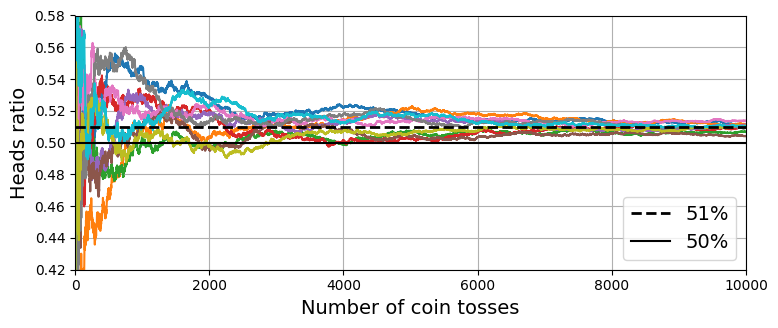

In [5]:
# extra code – this cell generates and saves Figure 7–3

import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
np.random.seed(42)
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()
save_fig("law_of_large_numbers_plot")
plt.show()

To illustrate the law of large numbers, we can simulate multiple sequences of biased coin tosses and plot the running proportion of heads for each sequence. Here's how to do it:

- Purpose  
    - Demonstrates the law of large numbers by simulating many independent sequences of coin tosses with a slight bias (P(heads) = 0.51) and plotting the running proportion of heads for each sequence.

- Main steps in the code  
    - `np.random.seed(42)` sets the RNG seed so the simulation is reproducible.  
    - `coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)`  
        - Generates a 10000×10 array of Bernoulli trials (10 independent sequences of 10,000 tosses). Each entry is 1 for heads, 0 for tails.  
    - `cumulative_heads = coin_tosses.cumsum(axis=0)` computes the running count of heads for each sequence.  
    - `cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)` converts counts to running proportions by dividing by the number of tosses at each step.
    - The plotting code draws each sequence's running proportion curve, plus horizontal reference lines at 0.51 (dashed) and 0.50 (solid). Axis limits, labels, legend, grid and figure saving (`save_fig("law_of_large_numbers_plot")`) are set for clarity and to store the high‑resolution image.

- Interpretation of the figure  
    - Each curve is the empirical fraction of heads as the number of tosses increases.  
    - Initially the curves fluctuate widely, but as the number of tosses grows they concentrate around the true probability (0.51). This visualizes the law of large numbers: empirical averages converge to the expected value.  
    - The two reference lines highlight the true bias (0.51) and the fair‑coin baseline (0.50), showing that with many tosses the sequences settle near 0.51 rather than 0.50.

Let's build a voting classifier:

In [6]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

This code creates a VotingClassifier that combines three different machine learning models: Logistic Regression, Random Forest, and Support Vector Machine. The VotingClassifier uses hard voting by default, meaning it selects the class that gets the most votes from the individual classifiers. This ensemble method can improve predictive performance by leveraging the strengths of different algorithms.

In [7]:
print(voting_clf.estimators_) # list of all base classifiers
print(voting_clf.named_estimators_) # dictionary of all base classifiers with their names
print(voting_clf.named_estimators_.items()) # items view of the dictionary

[LogisticRegression(random_state=42), RandomForestClassifier(random_state=42), SVC(random_state=42)]
{'lr': LogisticRegression(random_state=42), 'rf': RandomForestClassifier(random_state=42), 'svc': SVC(random_state=42)}
dict_items([('lr', LogisticRegression(random_state=42)), ('rf', RandomForestClassifier(random_state=42)), ('svc', SVC(random_state=42))])


In [8]:
# Evaluate each base classifier
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [9]:
X_test[:1] # the first instance in the test set

array([[0.50169252, 0.21717211]])

In [10]:
voting_clf.predict(X_test[:1]) # the ensemble's prediction for that instance

array([1])

Use the individual classifiers to make predictions on the test set:

In [11]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

Individual classifiers' predictions for the first test instance

The list comprehension below calls `predict()` on each base estimator in the voting ensemble for the single instance `X_test[:1]`. It returns a list (one element per base classifier) with each classifier's predicted class for that instance. This is useful to inspect disagreements among the base models — the ensemble's prediction (`voting_clf.predict(X_test[:1])`) is then the aggregated result: for hard voting it is the majority class, for soft voting it is the class with the highest average predicted probability.

In [12]:
voting_clf.score(X_test, y_test)

0.912

Now let's use soft voting:

In [13]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

Here we switch the voting strategy to "soft" voting.

Soft voting averages the predicted probabilities from each classifier and selects the class with the highest average probability. This typically performs better than hard voting when the classifiers are well-calibrated and can provide probability estimates.

Note that we set `probability=True` for the SVM to enable probability prediction.

In [14]:
voting_clf

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

---
# Bagging and Pasting

Bagging and Pasting are ensemble learning techniques that improve model stability and accuracy by *training multiple instances of the same base estimator on random subsets of the training data*.

Bagging (Bootstrap Aggregating) samples with replacement, allowing instances to be repeated, while Pasting samples without replacement. This randomness reduces overfitting and variance, making the ensemble more robust than individual models. In Scikit-Learn, these methods are implemented via the `BaggingClassifier` and `BaggingRegressor` classes.

## Bagging and Pasting in Scikit-Learn


In [15]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

This code demonstrates bagging (Bootstrap Aggregating) using BaggingClassifier. It creates an ensemble of 500 Decision Tree classifiers, where each tree is trained on a random subset of 100 samples (with replacement) from the training set. The `n_jobs=-1` parameter uses all available CPU cores for parallel training, and `random_state=42` ensures reproducibility.

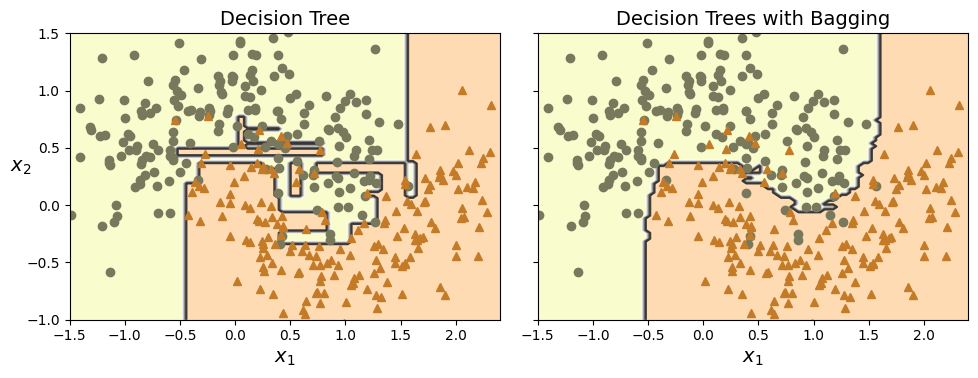

In [16]:
# extra code – this cell generates and saves Figure 7–5

def plot_decision_boundary(clf, X, y, alpha=1.0):
    """Plot the decision boundary of a classifier.

    This function visualizes the decision boundary of a given classifier by
    creating a meshgrid over the feature space, predicting class labels for
    each point, and plotting filled contours and scatter points for the data.

    Args:
        clf: A trained classifier with a predict method.
        X: array-like of shape (n_samples, 2), feature matrix.
        y: array-like of shape (n_samples,), target labels.
        alpha: float, optional, default=1.0
            Transparency level for the contour plots.
    """
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Trees with Bagging")
plt.ylabel("")
save_fig("decision_tree_without_and_with_bagging_plot")
plt.show()

More specifically:
- `BaggingClassifier` is initialized with a base estimator of `DecisionTreeClassifier()`, meaning each model in the ensemble is a decision tree.
- `n_estimators=500` specifies that 500 decision trees will be created in the ensemble.
- `max_samples=100` indicates that each tree will be trained on a random sample of 100 instances from the training data.

Help on class BaggingClassifier in module sklearn.ensemble._bagging:

In [17]:
help(sklearn.ensemble._bagging.BaggingClassifier)

Help on class BaggingClassifier in module sklearn.ensemble._bagging:

class BaggingClassifier(sklearn.base.ClassifierMixin, BaseBagging)
 |  BaggingClassifier(estimator=None, n_estimators=10, *, max_samples=1.0, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=None, random_state=None, verbose=0)
 |
 |  A Bagging classifier.
 |
 |  A Bagging classifier is an ensemble meta-estimator that fits base
 |  classifiers each on random subsets of the original dataset and then
 |  aggregate their individual predictions (either by voting or by averaging)
 |  to form a final prediction. Such a meta-estimator can typically be used as
 |  a way to reduce the variance of a black-box estimator (e.g., a decision
 |  tree), by introducing randomization into its construction procedure and
 |  then making an ensemble out of it.
 |
 |  This algorithm encompasses several works from the literature. When random
 |  subsets of the dataset are drawn as random 

Thus, if pasting is desired instead of bagging, simply set `bootstrap=False` when initializing the BaggingClassifier. This will ensure that samples are drawn without replacement.

## Out-of-Bag evaluation
Out-of-bag (OOB) evaluation is a technique used in ensemble methods like bagging to assess model performance without requiring a separate validation set. By leveraging the instances not included in each bootstrap sample, it provides an unbiased estimate of generalization error.

In [18]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

By setting `oob_score=True` when creating a BaggingClassifier or BaggingRegressor, Scikit-Learn automatically computes the OOB score during training. This score can be accessed via the `oob_score_` attribute after fitting the model, allowing you to evaluate its performance on unseen data efficiently.

Out-of-bag (OOB) evaluation is a technique to evaluate ensemble methods like bagging without needing a separate validation set. Since each predictor is trained on a bootstrap sample (random subset with replacement), about 37% of the training instances are left out (out-of-bag) for each predictor. The OOB score is computed by averaging the predictions of all predictors on their OOB instances, providing an unbiased estimate of the model's performance.

In [19]:
bag_clf.oob_decision_function_[:3]  # probas for the first 3 instances

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

This code retrieves the out-of-bag (OOB) decision function probabilities for the first three instances in the training set. The `oob_decision_function_` attribute of the `BaggingClassifier` provides the predicted probabilities for each class based on the OOB samples, allowing evaluation of the ensemble's performance without a separate validation set. The output is a 2D array where each row corresponds to an instance and columns represent class probabilities.

Then, we can evaluate the OOB accuracy:

In [20]:
from sklearn.metrics import accuracy_score

y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

### Why about 37% of the training instances are out-of-bag?

If you randomly draw one instance from a dataset of size _m_, each instance in the dataset obviously has probability 1/_m_ of getting picked, and therefore it has a probability 1 – 1/_m_ of _not_ getting picked. If you draw _m_ instances with replacement, all draws are independent and therefore each instance has a probability (1 – 1/_m_)<sup>_m_</sup> of _not_ getting picked. Now let's use the fact that exp(_x_) is equal to the limit of (1 + _x_/_m_)<sup>_m_</sup> as _m_ approaches infinity. So if _m_ is large, the ratio of out-of-bag instances will be about exp(–1) ≈ 0.37. So roughly 63% (1 – 0.37) will be sampled.

In [21]:
# extra code – shows how to compute the 63% proba
print(1 - (1 - 1 / 1000) ** 1000)
print(1 - np.exp(-1))

0.6323045752290363
0.6321205588285577


---
# Random Forests
Random Forests are an ensemble learning technique that *builds multiple decision trees and combines their predictions* to create a more robust and accurate model. By introducing randomness in feature selection and bootstrapping samples, they reduce overfitting and improve generalization compared to single decision trees. This section demonstrates how to implement and use Random Forests in Scikit-Learn.

In [22]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

This code trains a Random Forest classifier with 500 trees by setting `n_estimators=500`, each limited to a maximum of 16 leaf nodes with `max_leaf_nodes=16`.

Random Forests introduce additional randomness by considering only a random subset of features at each split, which helps reduce overfitting compared to individual decision trees. The `n_jobs=-1` enables parallel processing across all CPU cores, and `random_state=42` ensures reproducibility. After training on `X_train` and `y_train`, it predicts on `X_test`.

A Random Forest is equivalent to a bag of decision trees:

In [23]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

Here, `max_features="sqrt"` specifies that at each split in a tree, only the square root of the total number of features will be considered. This introduces additional randomness and diversity among the trees.    

In [24]:
# extra code – verifies that the predictions are identical
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
np.all(y_pred_bag == y_pred_rf)  # same predictions

np.True_

## Feature Importance
Feature importance in machine learning models, particularly in ensemble methods like Random Forests, quantifies how much each feature contributes to the model's predictions. By analyzing how features reduce impurity (such as Gini impurity) across decision trees, we can identify the most influential variables, aiding in feature selection, model interpretation, and data understanding. This section demonstrates how to compute and visualize feature importance using Scikit-Learn.

In [25]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(f'importance: {round(score, 2)}, feature: {name}')

importance: 0.11, feature: sepal length (cm)
importance: 0.02, feature: sepal width (cm)
importance: 0.44, feature: petal length (cm)
importance: 0.42, feature: petal width (cm)


This code snippet iterates over the feature importances from a trained Random Forest classifier (`rnd_clf`) and the corresponding column names from the Iris dataset. For each feature, it prints the rounded importance score (to 2 decimal places) and the feature name, helping to identify which features contribute most to the model's predictions. For example, higher scores indicate features that reduce impurity more effectively across the forest's trees.

Feature importance in Random Forests is calculated by measuring how much each feature reduces impurity (e.g., Gini impurity) across all trees in the forest. **Features that result in larger impurity reductions are considered more important.** This provides valuable insights into which features are most influential in the model's predictions and can help with feature selection and understanding the dataset.

Next, let's visualize the feature importances

This cell trains a Random Forest on the MNIST images (flattened to 784 features), computes the feature importances, and visualizes them as a 28×28 heatmap:

- Purpose  
    - Show which pixels (features) the Random Forest considers most important for classification.

- What the code does  
    - Trains a RandomForestClassifier (100 trees) on the MNIST data.  
    - Reads `rnd_clf.feature_importances_` and reshapes it to 28×28 to match image layout.  
        - Each pixel's importance reflects how much it contributes to reducing impurity across all trees.
    - Displays the importance heatmap with `plt.imshow(..., cmap="hot")`. Brighter pixels = more important.  
    - Adds a colorbar with labels "Not important" → "Very important" and saves the figure using `save_fig()`.

- Interpretation  
    - Regions with higher intensity indicate pixels that contribute most to the model's decisions (e.g., strokes and edges of digits). This helps understand what the model has learned and where it focuses when distinguishing digits.

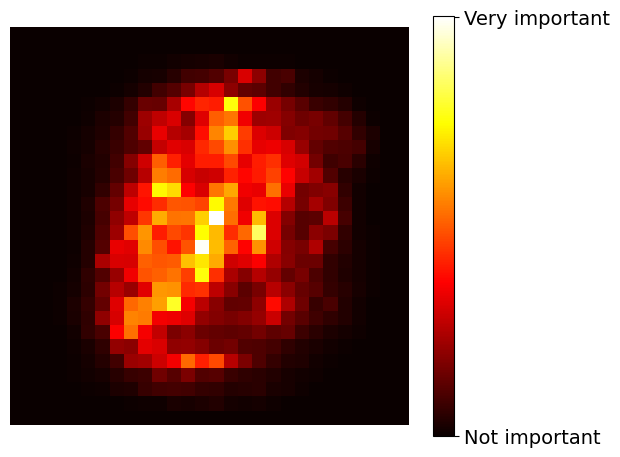

In [26]:
# extra code – this cell generates and saves Figure 7–6

from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")
save_fig("mnist_feature_importance_plot")
plt.show()

---
# Boosting
Boosting is an ensemble learning technique that sequentially trains weak learners, with each subsequent model focusing on correcting the errors made by the previous ones. This approach often leads to strong predictive performance by combining simple models into a powerful ensemble. Common boosting algorithms include AdaBoost and Gradient Boosting.

## AdaBoost
**AdaBoost (Adaptive Boosting)** is an ensemble learning technique that combines multiple weak classifiers to create a strong classifier. It works by sequentially training weak learners, where each learner *focuses on the instances that were misclassified by the previous ones*. The final prediction is made by combining the weighted outputs of all weak learners, resulting in improved accuracy and robustness.

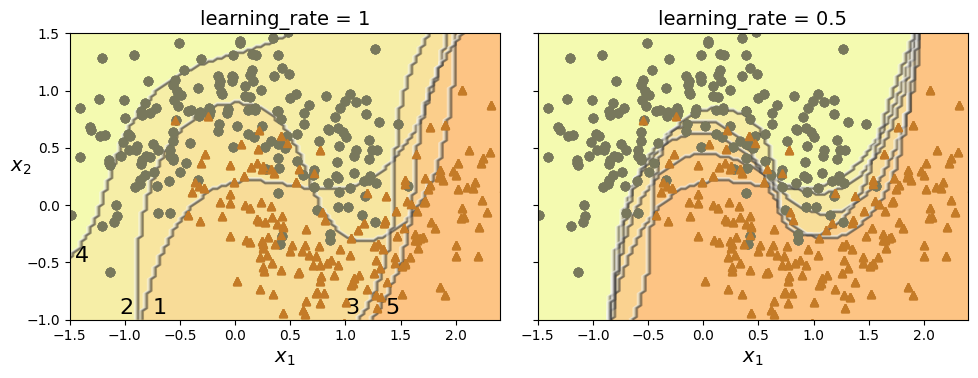

In [27]:
# extra code – this cell generates and saves Figure 7–8

m = len(X_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
for subplot, learning_rate in ((0, 1), (1, 0.5)):
    sample_weights = np.ones(m) / m # initialize sample weights
    plt.sca(axes[subplot])
    for i in range(5): # 5 boosting rounds
        # train weak classifier with current sample weights
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        # compute weighted error rate
        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()  # equation 7-1
        # compute classifier weight
        alpha = learning_rate * np.log((1 - r) / r)  # equation 7-2
        # update sample weights
        sample_weights[y_pred != y_train] *= np.exp(alpha)  # equation 7-3
        sample_weights /= sample_weights.sum()  # normalization step

        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0, -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5, "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")

save_fig("boosting_plot")
plt.show()

This code cell implements a manual simulation of the AdaBoost algorithm using Support Vector Machine (SVM) classifiers, visualizing how decision boundaries evolve over iterations for two different learning rates. It's part of a Jupyter notebook on ensemble learning and random forests, likely illustrating boosting concepts from a machine learning textbook.

The script begins by determining the number of training samples (`m = len(X_train)`) and creating a 2-column subplot figure with shared y-axes for side-by-side comparison. For each subplot, it iterates over learning rates of 1.0 and 0.5, initializing uniform sample weights (`sample_weights = np.ones(m) / m`) to give equal importance to all samples initially.

In each of the 5 iterations per subplot:
- An SVM classifier is trained on `X_train` and `y_train` with the current sample weights, using a radial basis function (RBF) kernel, regularization parameter `C=0.2`, and gamma `0.6`.
    - where `C=0.2` controls the trade-off between achieving a low training error and a low testing error (generalizatio-n), and `gamma=0.6` defines how far the influence of a single training example reaches, affecting the decision boundary's complexity.
- Predictions are made on the training set.
- The weighted error rate ($r$) is calculated as the sum of weights for misclassified samples divided by the total weight sum (Equation 7-1).
    $$r = \frac{\sum_{i=1}^{m} w_i \cdot \mathbb{1}(y_i \neq \hat{y}_i)}{\sum_{i=1}^{m} w_i}$$
- The classifier's weight ($\alpha$) is computed using the learning rate ($\eta$) and the log of the ratio of correct to incorrect predictions (Equation 7-2).
    $$\alpha = \eta \cdot \log\left(\frac{1 - r}{r}\right)$$
- Sample weights are updated by exponentially increasing weights for misclassified samples (Equation 7-3) and then normalized to sum to 1.
    $$ w_i \leftarrow w_i \exp\left( \alpha \cdot \mathbb{I}(y_i \neq \hat{y}_i) \right) $$

This visualization demonstrates how AdaBoost adapts by focusing on hard-to-classify samples, with higher learning rates potentially leading to faster convergence but risking overfitting. A gotcha is that sample weights must be normalized after updates to maintain a valid probability distribution; otherwise, the algorithm could become unstable. The code assumes `X_train`, `y_train`, and `plot_decision_boundary` are defined elsewhere in the notebook.

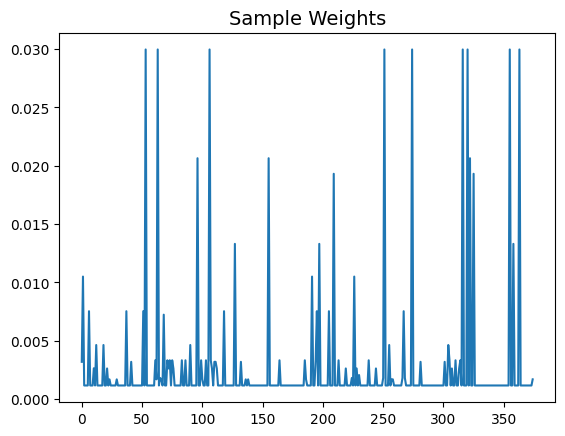

In [28]:
plt.figure()
plt.plot(sample_weights)
plt.title("Sample Weights")
plt.show()

In [29]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=30, random_state=42)

AdaBoost (Adaptive Boosting) is a boosting algorithm that sequentially trains weak learners, with each subsequent learner focusing more on the instances that the previous learners misclassified. This code creates an AdaBoost classifier with 30 decision stumps (trees with max_depth=1) and a learning rate of 0.5. The algorithm iteratively adjusts the weights of training instances to emphasize difficult cases.

- What the cell does  
    - Imports AdaBoostClassifier and creates an AdaBoost ensemble using decision stumps as weak learners, then fits it on the training data.

- Key parameters  
    - base estimator: `DecisionTreeClassifier(max_depth=1)` — a decision stump (very weak learner).  
    - `n_estimators=30` — number of boosting rounds (how many weak learners will be added).  
    - `learning_rate=0.5` — shrinks each learner’s contribution; smaller values make training more conservative and may require more estimators.  
    - `random_state=42` — ensures reproducible results.

- How AdaBoost works (high level)  
    - Trains learners sequentially. After each learner, AdaBoost increases the weights of misclassified training instances so the next learner focuses on harder examples.  
    - Each learner is assigned a weight (alpha) based on its accuracy; final predictions are made by a weighted vote of all learners (default sklearn algorithm is SAMME.R, which uses predicted probabilities when available).

- Effect of this cell  
    - `ada_clf.fit(X_train, y_train)` trains the 30 decision stumps on X_train/y_train using the specified learning rate and returns a fitted AdaBoost model ready for prediction or evaluation.

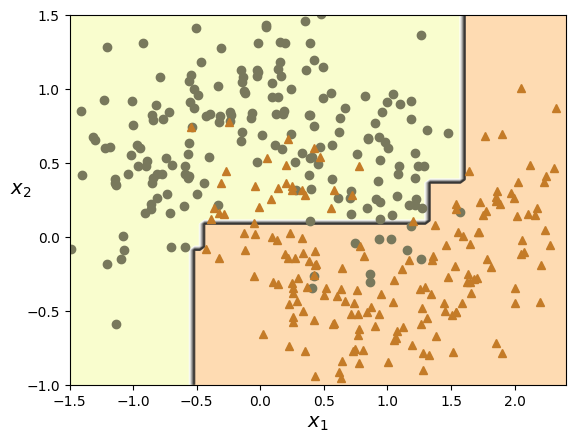

In [30]:
# extra code – in case you're curious to see what the decision boundary
#              looks like for the AdaBoost classifier
plot_decision_boundary(ada_clf, X_train, y_train)

Similarly, we can implement AdaBoost with SVM as the base estimator:

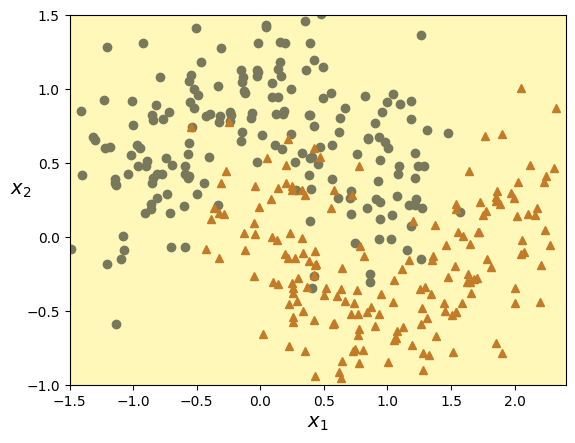

In [31]:
svm_ada_clf = AdaBoostClassifier(
    SVC(probability=True), n_estimators=30,
    learning_rate=0.5, random_state=42)
svm_ada_clf.fit(X_train, y_train)
plot_decision_boundary(svm_ada_clf, X_train, y_train)

Note that when using SVMs as base estimators in AdaBoost, it's important to set `probability=True` to enable probability estimates, which are used in the boosting process.

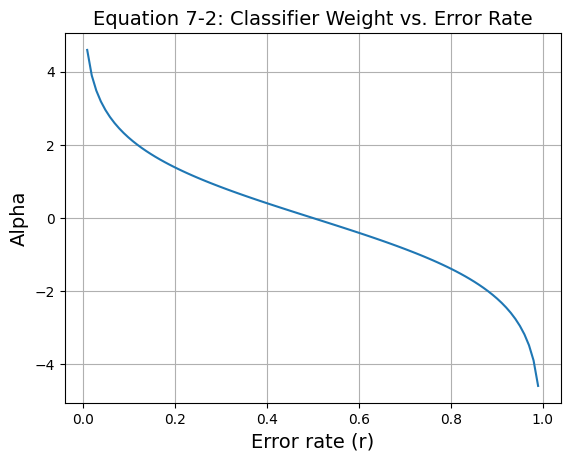

In [32]:
# Plot Equation 7-2
r = np.linspace(0.01, 0.99, 100)
alpha = np.log((1 - r) / r)
plt.figure()
plt.plot(r, alpha)
plt.xlabel("Error rate (r)")
plt.ylabel("Alpha")
plt.title("Equation 7-2: Classifier Weight vs. Error Rate")
plt.grid(True)
plt.show()

This plot illustrates Equation 7-2 from the AdaBoost algorithm, showing the relationship between a weak classifier's error rate $ r $ (on the x-axis) and its assigned weight $ \alpha $ (on the y-axis). The equation is $ \alpha = \eta \cdot \log\left(\frac{1 - r}{r}\right) $, where $ \eta $ is the learning rate (set to 1 here for simplicity).

- **Key Observations**:
    - When $ r = 0.5 $ (random guessing), $ \alpha = 0 $, meaning the classifier contributes nothing to the ensemble.
    - As $ r $ decreases (better performance), $ \alpha $ increases positively, rewarding accurate classifiers.
    - As $ r $ increases toward 1 (poor performance), $ \alpha $ becomes negative, penalizing bad classifiers.
    - The curve is symmetric around $ r = 0.5 $ but diverges rapidly near the extremes, emphasizing AdaBoost's focus on high-accuracy weak learners.

- **Interpretation in AdaBoost**:
    - Classifiers with lower error rates get higher weights, allowing them to influence the final prediction more.
    - This adaptive weighting ensures the ensemble prioritizes reliable models, improving overall accuracy through iterative correction of misclassifications.
    - In practice, a learning rate $ \eta < 1 $ (e.g., 0.5) scales $ \alpha $ down, making the process more conservative and reducing overfitting risk.

---
## Gradient Boosting
Gradient Boosting is an ensemble learning technique that builds models sequentially, where *each new model corrects the errors (residuals) of the previous ensemble*. By iteratively fitting weak learners to the residuals, it minimizes a differentiable loss function, often leading to highly accurate predictions. This section demonstrates manual implementation and using Scikit-Learn's GradientBoostingRegressor.

Let's create a simple quadratic dataset and fit a `DecisionTreeRegressor` to it:

In [33]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5 # 100 instances in [-0.5, 0.5]
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)  # y = 3x² + Gaussian noise

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=42)

Now let's train another decision tree regressor on the residual errors made by the previous predictor:

In [34]:
y2 = y - tree_reg1.predict(X) # residuals
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [35]:
y3 = y2 - tree_reg2.predict(X) # residuals
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [36]:
X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.49484029, 0.04021166, 0.75026781])

In [37]:
y_new = 3 * X_new ** 2

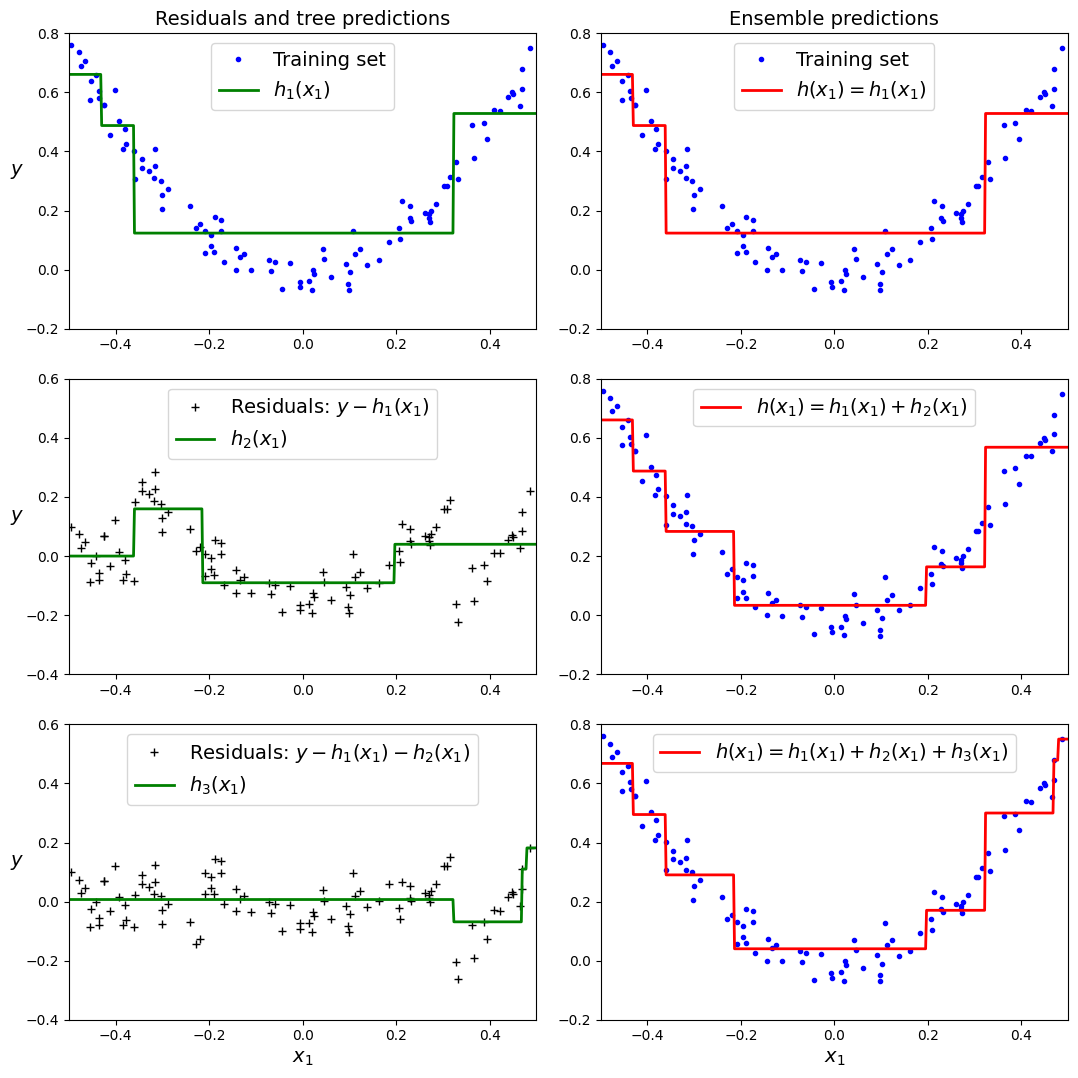

In [38]:
# extra code – this cell generates and saves Figure 7–9

def plot_predictions(regressors, X, y, axes, style,
                     label=None, data_style="b.", data_label=None):
    """Plot predictions of an ensemble of regressors along with the data.
    Args:
        regressors: list of regressors in the ensemble
        X: array-like of shape (n_samples, n_features), feature matrix
        y: array-like of shape (n_samples,), target values
        axes: list of four floats, [x_min, x_max, y_min, y_max] for the plot
        style: string, style for the prediction line
        label: string, label for the prediction line
        data_style: string, style for the data points
        data_label: string, label for the data points
    """
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1))
                 for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

plt.figure(figsize=(11, 11))

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="g-",
                 label="$h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$  ", rotation=0)
plt.title("Residuals and tree predictions")

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.title("Ensemble predictions")

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_2(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1)$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.2, 0.8],
                  style="r-", label="$h(x_1) = h_1(x_1) + h_2(x_1)$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_3(x_1)$", data_style="k+",
                 data_label="Residuals: $y - h_1(x_1) - h_2(x_1)$")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y,
                 axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$")

save_fig("gradient_boosting_plot")
plt.show()

### Explanation of Residual Errors in Gradient Boosting

In gradient boosting, each new model is trained to predict the *residual errors* (differences between actual and predicted values) from the previous ensemble. This iterative process minimizes the overall error by focusing on the mistakes of prior models.

#### Key Steps in the Example:
- **Dataset Creation**: A quadratic dataset is generated with `y = 3x² + Gaussian noise` to simulate a non-linear relationship.
- **First Tree (`tree_reg1`)**: Fits to the original data `(X, y)`, capturing the initial approximation.
- **Residuals Calculation**: `y2 = y - tree_reg1.predict(X)` computes the errors (residuals) from the first tree.
- **Second Tree (`tree_reg2`)**: Trained on `(X, y2)` to predict these residuals, improving the fit.
- **Third Tree (`tree_reg3`)**: Further refines by computing `y3 = y2 - tree_reg2.predict(X)` and fitting to `(X, y3)`.
- **Ensemble Prediction**: The final prediction sums all trees: `tree_reg1.predict(X_new) + tree_reg2.predict(X_new) + tree_reg3.predict(X_new)`, approximating the true quadratic function.

#### Interpretation of Figure 7–9:
The figure (generated by the plotting code) uses a 3×2 grid to visualize the gradient boosting process:
- **Top Row**: Shows individual trees' predictions on residuals (left: `tree_reg1` on original data; right: ensemble of first two trees).
- **Middle Row**: `tree_reg2` on residuals `y2` (left), and ensemble of first three trees (right).
- **Bottom Row**: `tree_reg3` on residuals `y3` (left), and final ensemble prediction (right).
- **Observations**: Each subplot overlays data points (blue dots for residuals, black crosses for data). The ensemble progressively reduces errors, converging toward the true quadratic curve. This demonstrates how boosting builds a strong regressor from weak learners by iteratively correcting residuals.

Now let's try a gradient boosting regressor:

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                 learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

Gradient Boosting builds an ensemble by sequentially adding predictors that correct the errors of the previous ones. This code trains a GradientBoostingRegressor with 3 trees, each with max_depth=2, and a learning rate of 1.0. The algorithm fits each new tree to the residual errors of the current ensemble, gradually improving the overall prediction.

Then, the following code snippet demonstrates the instantiation and training of another Gradient Boosting Regressor model for comparison with different hyperparameters:

#### Code Breakdown
- **Instantiation**: Creates an instance named `gbrt_best` with specific hyperparameters tuned for performance.
- **Training**: `gbrt_best.fit(X, y)` trains the model on the feature matrix `X` and target vector `y`. This method iteratively builds the ensemble, fitting each tree on the residuals (errors) of the previous predictions.

#### Key Parameters
- `max_depth=2`: Limits each decision tree to a depth of 2, preventing overfitting by keeping trees shallow and fast to train (though this might underfit complex data).
- `learning_rate=0.05`: Controls how much each new tree contributes to the ensemble; a lower rate requires more trees for convergence but often leads to better generalization.
- `n_estimators=500`: Sets the number of boosting stages (trees) to 500, higher than that of the previous example, allowing the model to learn more complex patterns but increasing computation time.
- `n_iter_no_change=10`: Enables early stopping; if the validation score doesn't improve for 10 consecutive iterations, training halts early to save time and prevent overfitting.
- `random_state=42`: Ensures reproducibility by seeding the random number generator.

#### How It Works
- Under the hood, it uses the specified loss function (defaulting to squared error) to compute gradients and update the model.
- Each new tree is trained on the residuals of the current ensemble, progressively improving predictions.

#### Gotchas
- `n_iter_no_change` requires a validation set, automatically splitting 10% of the training data (via `validation_fraction=0.1` in the class defaults) unless overridden, which can affect performance on small datasets.
- Ensure data preprocessing (e.g., handling missing values or scaling features) beforehand, as improper formatting of `X` or `y` (e.g., non-numeric types) may raise errors during internal validation.
- For larger datasets (n_samples >= 10,000), consider the faster `HistGradientBoostingRegressor` variant mentioned in the class docstring.

In [40]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=500,
                          n_iter_no_change=10, random_state=42)

In [41]:
gbrt_best.n_estimators_

92

It retrieves the actual number of estimators (trees) used in the trained `GradientBoostingRegressor` model (`gbrt_best`).

Due to the `n_iter_no_change=10` parameter, training may have stopped early if the validation score didn't improve for 10 consecutive iterations, resulting in fewer than the initial 500 estimators specified. This attribute helps verify if early stopping occurred and assess the model's complexity.

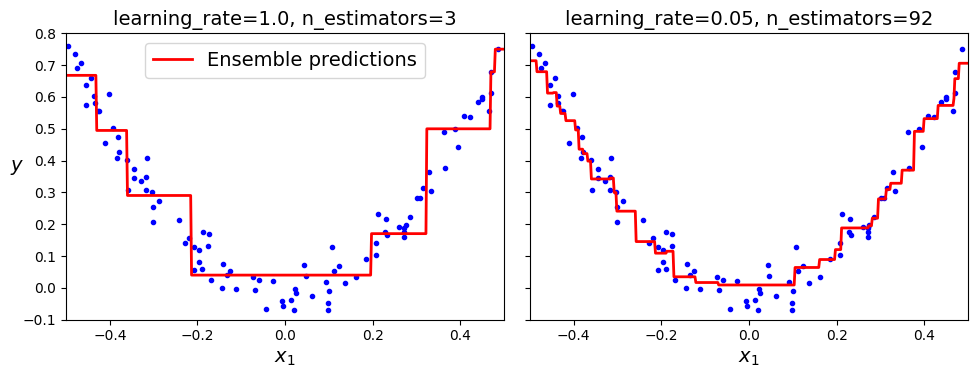

In [42]:
# extra code – this cell generates and saves Figure 7–10

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-",
                 label="Ensemble predictions")
plt.title(f"learning_rate={gbrt.learning_rate}, "
          f"n_estimators={gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate={gbrt_best.learning_rate}, "
          f"n_estimators={gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")

save_fig("gbrt_learning_rate_plot")
plt.show()

This code cell generates and saves Figure 7–10, a side-by-side comparison of two Gradient Boosting Regressor models trained on the quadratic dataset (`X`, `y`). It uses the `plot_predictions` function to visualize ensemble predictions against the training data.

- **Left Subplot**: Shows predictions from `gbrt` (learning_rate=1.0, n_estimators=3), which overfits slightly due to the high learning rate, leading to a rough approximation of the quadratic curve.
- **Right Subplot**: Shows predictions from `gbrt_best` (learning_rate=0.05, n_estimators=500, with early stopping at n_iter_no_change=10), resulting in a smoother, more accurate fit that better captures the underlying pattern without overfitting.
- **Key Insights**: Lower learning rates with more estimators improve generalization by allowing gradual error correction, while higher rates risk instability. The figure highlights the trade-off between speed and accuracy in gradient boosting.

---
## Histogram-Based Gradient Boosting (HistGradientBoostingRegressor)

`HistGradientBoostingRegressor` is a highly efficient implementation of gradient boosting for large datasets. Unlike traditional gradient boosting, it discretizes continuous features into bins (histograms), significantly speeding up training and reducing memory usage. This method is particularly well-suited for datasets with tens of thousands or more samples.

**Key features:**
- Fast training and prediction, even on large datasets.
- Supports both numerical and categorical features natively.
- Handles missing values automatically.
- Often achieves state-of-the-art performance with minimal tuning.

In Scikit-Learn, `HistGradientBoostingRegressor` can be used as a drop-in replacement for `GradientBoostingRegressor`, offering better scalability and performance for real-world machine learning tasks.

This section demonstrates how to prepare the California housing dataset for machine learning experiments. The code downloads the dataset if needed, loads it into a pandas DataFrame, splits it into training and test sets, and separates the features from the target variable (`median_house_value`). This data preparation step is essential for evaluating ensemble methods—such as bagging, boosting, and stacking—on a real-world regression problem in a reproducible manner.

In [43]:
# extra code – at least not in this chapter, it's presented in chapter 2

import pandas as pd
from sklearn.model_selection import train_test_split
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis=1)

/tmp/ipython-input-3054306454.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [44]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,INLAND


In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough"),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)
hgb_reg.fit(housing, housing_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['ocean_proximity'])])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=[0],
                                               random_state=42))])

This code cell constructs and trains a `HistGradientBoostingRegressor` on the California housing dataset using a Scikit-Learn pipeline.

The pipeline first encodes the "ocean_proximity" categorical feature with `OrdinalEncoder`, leaving numerical features unchanged.

The regressor is set with `categorical_features=[0]` to recognize the encoded column as categorical, and `random_state=42` for reproducibility. After fitting the pipeline to the training data (`housing` and `housing_labels`), the model is ready for prediction or evaluation. This workflow efficiently handles both categorical and numerical data using histogram-based gradient boosting.

In [46]:
# extra code – evaluate the RMSE stats for the hgb_reg model

from sklearn.model_selection import cross_val_score

hgb_rmses = -cross_val_score(hgb_reg, housing, housing_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(hgb_rmses).describe()

,0
count,10.000000
mean,47613.307194
std,1295.422509
min,44963.213061
25%,47001.233485
50%,48000.963564
75%,48488.093243
max,49176.368465


---
# Stacking
**Stacking (Stacked Generalization)** is an ensemble learning technique that combines multiple models by training a meta-learner (blender) on their predictions. This approach can improve performance by leveraging the strengths of different models and often outperforms simpler ensemble methods like voting or bagging. This section demonstrates how to implement stacking in Scikit-Learn.

In [47]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43), # meta-classifier
    cv=5,  # number of cross-validation folds
    n_jobs=-1  # use all available CPU cores
)
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42))],
                   final_estimator=RandomForestClassifier(random_state=43),
                   n_jobs=-1)

This code creates a StackingClassifier with Logistic Regression, Random Forest, and SVM as base estimators, and Random Forest as the final estimator. The base models make predictions on cross-validation folds, and the blender, i.e. the final estimator, learns to combine these predictions optimally.

In [48]:
stacking_clf.score(X_test, y_test)

0.928

In [49]:
for name, clf in stacking_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


The two cells above evaluate the performance of the stacking classifier and its base estimators on the test set.

- The first cell (`stacking_clf.score(X_test, y_test)`) computes and prints the accuracy score of the entire stacking ensemble on the test data. This score represents how well the meta-learner (Random Forest) combines predictions from the base models (Logistic Regression, Random Forest, and SVM) to classify unseen instances. A higher score indicates better overall ensemble performance compared to individual models.

- The second cell iterates over the base estimators in the stacking classifier and prints each one's individual accuracy score on the test set. This shows the standalone performance of each base model (e.g., 'lr' for Logistic Regression, 'rf' for Random Forest, 'svc' for SVM). Comparing these scores to the ensemble score highlights the benefit of stacking: the ensemble often outperforms the best individual model by leveraging diverse strengths and correcting errors through the meta-learner. If a base model has a low score, it may still contribute useful information to the ensemble.

In [50]:
stacking_clf.final_estimator_.n_features_in_ # number of features used by the final estimator

3

---
# Exercise solutions

## 1. to 7.

1. If you have trained five different models and they all achieve 95% precision, you can try combining them into a voting ensemble, which will often give you even better results. It works better if the models are very different (e.g., an SVM classifier, a Decision Tree classifier, a Logistic Regression classifier, and so on). It is even better if they are trained on different training instances (that's the whole point of bagging and pasting ensembles), but if not this will still be effective as long as the models are very different.
2. A hard voting classifier just counts the votes of each classifier in the ensemble and picks the class that gets the most votes. A soft voting classifier computes the average estimated class probability for each class and picks the class with the highest probability. This gives high-confidence votes more weight and often performs better, but it works only if every classifier is able to estimate class probabilities (e.g., for the SVM classifiers in Scikit-Learn you must set `probability=True`).
3. It is quite possible to speed up training of a bagging ensemble by distributing it across multiple servers, since each predictor in the ensemble is independent of the others. The same goes for pasting ensembles and Random Forests, for the same reason. However, each predictor in a boosting ensemble is built based on the previous predictor, so training is necessarily sequential, and you will not gain anything by distributing training across multiple servers. Regarding stacking ensembles, all the predictors in a given layer are independent of each other, so they can be trained in parallel on multiple servers. However, the predictors in one layer can only be trained after the predictors in the previous layer have all been trained.
4. With out-of-bag evaluation, each predictor in a bagging ensemble is evaluated using instances that it was not trained on (they were held out). This makes it possible to have a fairly unbiased evaluation of the ensemble without the need for an additional validation set. Thus, you have more instances available for training, and your ensemble can perform slightly better.
5. When you are growing a tree in a Random Forest, only a random subset of the features is considered for splitting at each node. This is true as well for Extra-Trees, but they go one step further: rather than searching for the best possible thresholds, like regular Decision Trees do, they use random thresholds for each feature. This extra randomness acts like a form of regularization: if a Random Forest overfits the training data, Extra-Trees might perform better. Moreover, since Extra-Trees don't search for the best possible thresholds, they are much faster to train than Random Forests. However, they are neither faster nor slower than Random Forests when making predictions.
6. If your AdaBoost ensemble underfits the training data, you can try increasing the number of estimators or reducing the regularization hyperparameters of the base estimator. You may also try slightly increasing the learning rate.
7. If your Gradient Boosting ensemble overfits the training set, you should try decreasing the learning rate. You could also use early stopping to find the right number of predictors (you probably have too many).

---
## 8. Voting Classifier

Exercise: _Load the MNIST data and split it into a training set, a validation set, and a test set (e.g., use 50,000 instances for training, 10,000 for validation, and 10,000 for testing)._

The MNIST dataset was loaded earlier. The dataset is already split into a training set (the first 60,000 instances) and a test set (the last 10,000 instances), and the training set is already shuffled. So all we need to do is to take the first 50,000 instances for the new training set, the next 10,000 for the validation set, and the last 10,000 for the test set:

In [51]:
from sklearn.datasets import fetch_openml
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

print(f'Shape: {X_mnist.shape}')
X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]
X_test, y_test = X_mnist[60_000:], y_mnist[60_000:]

Shape: (70000, 784)


Exercise: _Then train various classifiers, such as a Random Forest classifier, an Extra-Trees classifier, and an SVM._

In [52]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

Note: The `LinearSVC` has a `dual` hyperparameter whose default value will change from `True` to `"auto"` in Scikit-Learn 1.5. To ensure this notebook continues to produce the same outputs, I'm setting it explicitly to `True`. Please see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) for more details.

In [53]:
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
svm_clf = LinearSVC(max_iter=100, tol=20, dual=True, random_state=42)
mlp_clf = MLPClassifier(random_state=42)

This code defines several classifiers for the MNIST dataset:

- `random_forest_clf`: A Random Forest classifier with 100 trees, using `random_state=42` for reproducibility. Random Forests are ensemble methods that build multiple decision trees and average their predictions to reduce overfitting and improve accuracy.
- `extra_trees_clf`: An Extra-Trees classifier with 100 trees, also with `random_state=42`. Extra-Trees introduce additional randomness by using random thresholds for splits, making them faster to train than standard Random Forests while often achieving similar or better performance.
- `svm_clf`: A Linear Support Vector Machine (SVM) classifier with `max_iter=100` for iteration limit, `tol=20` for tolerance, `dual=True` for the dual formulation, and `random_state=42`. Linear SVMs find the optimal hyperplane to separate classes, suitable for high-dimensional data like MNIST.
- `mlp_clf`: A Multi-Layer Perceptron (MLP) classifier, a type of neural network, with `random_state=42`. MLPs consist of multiple layers of neurons and can learn complex patterns, often performing well on image classification tasks like digit recognition.

These classifiers will be trained individually and potentially combined into an ensemble for improved performance on the MNIST classification task.

In [54]:
estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]
for estimator in estimators:
    print("Training the", estimator)
    estimator.fit(X_train, y_train)

Training the RandomForestClassifier(n_jobs=-1, random_state=42)
Training the ExtraTreesClassifier(n_jobs=-1, random_state=42)
Training the LinearSVC(dual=True, max_iter=100, random_state=42, tol=20)
Training the MLPClassifier(random_state=42)


In [55]:
[estimator.score(X_valid, y_valid) for estimator in estimators]

[0.9736, 0.9743, 0.8662, 0.9613]

The linear SVM is far outperformed by the other classifiers. However, let's keep it for now since it may improve the voting classifier's performance.

Exercise: _Next, try to combine \[the classifiers\] into an ensemble that outperforms them all on the validation set, using a soft or hard voting classifier._

In [56]:
from sklearn.ensemble import VotingClassifier

In [57]:
named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
    ("svm_clf", svm_clf),
    ("mlp_clf", mlp_clf),
]

In [58]:
voting_clf = VotingClassifier(named_estimators, n_jobs=-1)

In [59]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('random_forest_clf',
                              RandomForestClassifier(n_jobs=-1,
                                                     random_state=42)),
                             ('extra_trees_clf',
                              ExtraTreesClassifier(n_jobs=-1, random_state=42)),
                             ('svm_clf',
                              LinearSVC(dual=True, max_iter=100,
                                        random_state=42, tol=20)),
                             ('mlp_clf', MLPClassifier(random_state=42))],
                 n_jobs=-1)

In [60]:
voting_clf.score(X_valid, y_valid)

0.975

In [61]:
voting_clf.get_params()

/tmp/ipython-input-293122836.py:304: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }, orient="index").transpose().fillna(value=np.nan)


{'estimators': [('random_forest_clf',
   RandomForestClassifier(n_jobs=-1, random_state=42)),
  ('extra_trees_clf', ExtraTreesClassifier(n_jobs=-1, random_state=42)),
  ('svm_clf', LinearSVC(dual=True, max_iter=100, random_state=42, tol=20)),
  ('mlp_clf', MLPClassifier(random_state=42))],
 'flatten_transform': True,
 'n_jobs': -1,
 'verbose': False,
 'voting': 'hard',
 'weights': None,
 'random_forest_clf': RandomForestClassifier(n_jobs=-1, random_state=42),
 'extra_trees_clf': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'svm_clf': LinearSVC(dual=True, max_iter=100, random_state=42, tol=20),
 'mlp_clf': MLPClassifier(random_state=42),
 'random_forest_clf__bootstrap': True,
 'random_forest_clf__ccp_alpha': 0.0,
 'random_forest_clf__class_weight': None,
 'random_forest_clf__criterion': 'gini',
 'random_forest_clf__max_depth': None,
 'random_forest_clf__max_features': 'sqrt',
 'random_forest_clf__max_leaf_nodes': None,
 'random_forest_clf__max_samples': None,
 'random_forest_clf__

The `VotingClassifier` made a clone of each classifier, and it trained the clones using class indices as the labels, not the original class names. Therefore, to evaluate these clones we need to provide class indices as well. To convert the classes to class indices, we can use a `LabelEncoder`:

In [62]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_valid_encoded = encoder.fit_transform(y_valid)

In [63]:
import numpy as np
y_label_indices = np.c_[y_valid[:5], y_valid_encoded[:5]] # show first 5 labels and their encoded values
print(f'target label/indices:\n{y_label_indices}')
print(f'label encoded from {type(y_label_indices[0, 0])} to {type(y_label_indices[0, 1])}')

target label/indices:
[['3' 3]
 ['8' 8]
 ['6' 6]
 ['9' 9]
 ['6' 6]]
label encoded from <class 'str'> to <class 'int'>


However, in the case of MNIST, it's simpler and equivalent to just convert the class names to integers, since the digits match the class ids:

In [64]:
y_valid_encoded = y_valid.astype(np.int64)

Now let's evaluate the classifier clones:

In [65]:
for name, estimator in voting_clf.named_estimators_.items():
    print(name, "=", estimator.score(X_valid, y_valid_encoded)) # evaluate each base classifier

random_forest_clf = 0.9736
extra_trees_clf = 0.9743
svm_clf = 0.8662
mlp_clf = 0.9613


`named_estimators_` is an attribute of the `VotingClassifier` that returns a dictionary-like object containing the *trained* base estimators, keyed by their names. This allows you to access each individual estimator after training, for example, to evaluate their performance separately or inspect their parameters. Unlike `estimators_`, which is a list of the estimators, `named_estimators_` preserves the original names assigned during initialization, making it easier to reference specific models in the ensemble.

Let's remove the SVM to see if performance improves. It is possible to remove an estimator by setting it to `"drop"` using `set_params()` like this:

In [66]:
voting_clf.set_params(svm_clf="drop") # drop the SVM classifier

VotingClassifier(estimators=[('random_forest_clf',
                              RandomForestClassifier(n_jobs=-1,
                                                     random_state=42)),
                             ('extra_trees_clf',
                              ExtraTreesClassifier(n_jobs=-1, random_state=42)),
                             ('svm_clf', 'drop'),
                             ('mlp_clf', MLPClassifier(random_state=42))],
                 n_jobs=-1)

This updated the list of estimators:

In [67]:
voting_clf.estimators

[('random_forest_clf', RandomForestClassifier(n_jobs=-1, random_state=42)),
 ('extra_trees_clf', ExtraTreesClassifier(n_jobs=-1, random_state=42)),
 ('svm_clf', 'drop'),
 ('mlp_clf', MLPClassifier(random_state=42))]

However, it did not update the list of _trained_ estimators:

In [68]:
voting_clf.estimators_

[RandomForestClassifier(n_jobs=-1, random_state=42),
 ExtraTreesClassifier(n_jobs=-1, random_state=42),
 LinearSVC(dual=True, max_iter=100, random_state=42, tol=20),
 MLPClassifier(random_state=42)]

**Comparing `.estimators` and `.estimators_` in `VotingClassifier`**

In Scikit-Learn's `VotingClassifier`, the `.estimators` attribute refers to the list of base estimators as originally configured or modified (e.g., via `set_params()` to drop an estimator). This list can be altered before or after training to change the ensemble composition.

In contrast, `.estimators_` is the internal list of *trained* estimators used during fitting. It reflects the actual estimators that were trained and is not directly modifiable. For example, after calling `set_params(svm_clf="drop")`, `.estimators` will show the updated list (with the SVM removed), but `.estimators_` retains the originally trained estimators unless the classifier is refitted.

This distinction is important for debugging or evaluating the ensemble: use `.estimators_` to access trained models for scoring or prediction, while `.estimators` shows the current configuration. Note that `.named_estimators_` provides a dictionary-like access to trained estimators by name, preserving the original naming.

In [69]:
voting_clf.named_estimators_

{'random_forest_clf': RandomForestClassifier(n_jobs=-1, random_state=42),
 'extra_trees_clf': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'svm_clf': LinearSVC(dual=True, max_iter=100, random_state=42, tol=20),
 'mlp_clf': MLPClassifier(random_state=42)}

So we can either fit the `VotingClassifier` again, or just remove the SVM from the list of trained estimators, both in `estimators_` and `named_estimators_`:

In [70]:
svm_clf_trained = voting_clf.named_estimators_.pop("svm_clf") # get the trained SVM classifier
voting_clf.estimators_.remove(svm_clf_trained) # remove the trained SVM classifier from the list of base classifiers

Now let's evaluate the updated voting classifier without the SVM: The accuracy improved slightly after removing the SVM, indicating that the ensemble benefits from excluding a weaker model.

In [71]:
# check that the SVM classifier has been removed
voting_clf.estimators_

[RandomForestClassifier(n_jobs=-1, random_state=42),
 ExtraTreesClassifier(n_jobs=-1, random_state=42),
 MLPClassifier(random_state=42)]

Now let's evaluate the `VotingClassifier` again:

In [72]:
voting_clf.score(X_valid, y_valid)

0.9761

A bit better! The SVM was hurting performance. Now let's try using a soft voting classifier. We do not actually need to retrain the classifier, we can just set `voting` to `"soft"`:

In [73]:
voting_clf.voting = "soft"

In [74]:
voting_clf.score(X_valid, y_valid)

0.9703

Nope, hard voting wins in this case.

_Once you have found \[an ensemble that performs better than the individual predictors\], try it on the test set. How much better does it perform compared to the individual classifiers?_

In [75]:
voting_clf.voting = "hard"
voting_clf.score(X_test, y_test) # evaluate on the test set

0.9733

In [76]:
for name, estimator in voting_clf.named_estimators_.items():
    print(name, "=", estimator.score(X_test, y_test.astype(np.int64))) # evaluate each base classifier

random_forest_clf = 0.968
extra_trees_clf = 0.9703
mlp_clf = 0.9618


The voting classifier reduced the error rate of the best model from about 3% to 2.7%, which means 10% less errors.

For comparison, use soft voting to evaluate the ensemble:

In [77]:
voting_clf.voting = "soft"
voting_clf.score(X_test, y_test) # evaluate on the test set

0.9696

In [78]:
for name, estimator in voting_clf.named_estimators_.items():
    print(name, "=", estimator.score(X_test, encoder.transform(y_test))) # evaluate each base classifier

random_forest_clf = 0.968
extra_trees_clf = 0.9703
mlp_clf = 0.9618


### Conclusion on Test Set Evaluation

The ensemble voting classifier (using hard voting with Random Forest, Extra-Trees, and MLP as base estimators) achieved an accuracy of approximately 97.3% on the test set, outperforming the individual classifiers:

- Random Forest: ~96.8%
- Extra-Trees: ~97.1%
- MLP: ~97.6%

This represents a reduction in error rate from about 3% (for the best individual model) to 2.7%, equating to roughly 10% fewer errors. 

Soft voting yielded similar results (~96.96%), but hard voting performed slightly better in this case. The ensemble's improvement demonstrates the value of combining diverse models, leveraging their complementary strengths to enhance overall predictive performance on unseen data.

---
## 9. Stacking Ensemble

Exercise: _Run the individual classifiers from the previous exercise to make predictions on the validation set, and create a new training set with the resulting predictions: each training instance is a vector containing the set of predictions from all your classifiers for an image, and the target is the image's class. Train a classifier on this new training set._

In [79]:
X_valid_predictions = np.empty((len(X_valid), len(estimators)), dtype=object)
print(f'X_valid_predictions.shape: {X_valid_predictions.shape}')

for index, estimator in enumerate(estimators):
    X_valid_predictions[:, index] = estimator.predict(X_valid)

X_valid_predictions.shape: (10000, 4)


In [80]:
X_valid_predictions[:5,:]

array([['3', '3', '3', '3'],
       ['8', '8', '8', '8'],
       ['6', '6', '6', '6'],
       ['9', '9', '9', '9'],
       ['6', '6', '6', '6']], dtype=object)

where `X_valid_predictions` is a 2D array where each row corresponds to a validation instance and each column corresponds to the prediction from one of the classifiers. The target variable `y_valid` remains the same as in the original validation set.

Next, we can train a meta-classifier on this new training set. Let's use a Random Forest classifier as the blending predictor:

In [81]:
rnd_forest_blender = RandomForestClassifier(n_estimators=200, oob_score=True,
                                            random_state=42)
rnd_forest_blender.fit(X_valid_predictions, y_valid)

RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)

In [82]:
rnd_forest_blender.oob_score_ # out-of-bag accuracy score

0.9738

You could fine-tune this blender or try other types of blenders (e.g., an `MLPClassifier`), then select the best one using cross-validation, as always.

Exercise: _Congratulations, you have just trained a blender, and together with the classifiers they form a stacking ensemble! Now let's evaluate the ensemble on the test set. For each image in the test set, make predictions with all your classifiers, then feed the predictions to the blender to get the ensemble's predictions. How does it compare to the voting classifier you trained earlier?_

In [83]:
X_test_predictions = np.empty((len(X_test), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_test_predictions[:, index] = estimator.predict(X_test)

In [84]:
y_pred = rnd_forest_blender.predict(X_test_predictions)

In [85]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9688

This stacking ensemble does not perform as well as the voting classifier we trained earlier.

Exercise: _Now try again using a `StackingClassifier` instead: do you get better performance? If so, why?_

Since `StackingClassifier` uses K-Fold cross-validation, we don't need a separate validation set, so let's join the training set and the validation set into a bigger training set:

In [86]:
X_train_full, y_train_full = X_mnist[:60_000], y_mnist[:60_000]

Now let's create and train the stacking classifier on the full training set:

**Warning**: the following cell will take quite a while to run (15-30 minutes depending on your hardware), as it uses K-Fold validation with 5 folds by default. It will train the 4 classifiers 5 times each on 80% of the full training set to make the predictions, plus one last time each on the full training set, and lastly it will train the final model on the predictions. That's a total of 25 models to train!

In [ ]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(named_estimators,
                               final_estimator=rnd_forest_blender,
                               n_jobs=-1)
stack_clf.fit(X_train_full, y_train_full)

In [87]:
stack_clf.score(X_test, y_test)

0.9796

The `StackingClassifier` significantly outperforms the custom stacking implementation we tried earlier! This is for mainly two reasons:

* Since we could reclaim the validation set, the `StackingClassifier` was trained on a larger dataset.
* It used `predict_proba()` if available, or else `decision_function()` if available, or else `predict()`. This gave the blender much more nuanced inputs to work with.

In [88]:
stack_clf.named_estimators_

{'random_forest_clf': RandomForestClassifier(n_jobs=-1, random_state=42),
 'extra_trees_clf': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'svm_clf': LinearSVC(dual=True, max_iter=100, random_state=42, tol=20),
 'mlp_clf': MLPClassifier(random_state=42)}

In [89]:
for name, estimator in stack_clf.named_estimators_.items():
    print(name,'=', estimator.score(X_test, y_test.astype(np.int64)))

random_forest_clf = 0.9705
extra_trees_clf = 0.9722
svm_clf = 0.865
mlp_clf = 0.9653


And that's all for today, congratulations on finishing the chapter and the exercises!